In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df=pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()
#print(df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()#here i check the missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()#yeh code mujhe batayega ki koi duplicated row hai toh 0 araha hai toh koi duplicated row nhi hai 


0

In [6]:
df['Exited'].value_counts()#yeh batayega kitne logo ne bank leave kiya 

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True, errors='ignore')


In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
#here we do onehot encoding
'''
jo humare pas 3 category tha usse humne 2 column bana liye geography germany and geography 
spain and geography france delete hogaya or toh in 2 column se hume 3 category dikha sakte hai 
jaise 0 0 france hogaya and jo humare 2 gender tha usse humne ek gender bana liye gender male 
so similarly hum ek column se 2 category dikha sakte hai 0 ka matlab female hogaya

'''
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)


In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [13]:
X=df.drop(columns=['Exited'])#hum last wale coulmn ko temprory drop karenge
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [14]:
X_train.shape

(8000, 11)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [16]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [17]:
'''
aab hum kearas apply karenge
'''
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [18]:
'''
abhi hum log sequential model banyege abhi bas just hum log start kar rahe hai
'''
model=Sequential()# model ka object create kiya hai

model.add(Dense(11,activation='relu',input_dim=11))# 3 indicate node or percept. input_dim indicate aabhi humare pas total 11 input hai
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))# yeh humara output layer hai 1 node is for output  

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
#summary() function apke model ka summary dega
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
'''
itna karne ke baad hum humare model ko compile karna padta hai 
compile stage mei aap kuch cheez batate ho aap konsa loss function used karoge aap
konsa optimizer used karoge gradient descent ke liye 
'''
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [21]:
'''
aab hum humare last stage mein model ko fit karenge 
'''
#epochs batyega ki kitni baar aap apne data par ghumoge to findout this weight and biases 
#toh abhi hum 10 baar ghumenge 
#and humne validation split add kiya hai iska matlab 8000 logo mein se 20% subtract karke check karega

history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6340 - loss: 0.6534 - val_accuracy: 0.7975 - val_loss: 0.4758
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7949 - loss: 0.4669 - val_accuracy: 0.7994 - val_loss: 0.4450
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.4422 - val_accuracy: 0.8006 - val_loss: 0.4338
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7939 - loss: 0.4427 - val_accuracy: 0.8075 - val_loss: 0.4251
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8048 - loss: 0.4214 - val_accuracy: 0.8119 - val_loss: 0.4146
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8116 - loss: 0.4146 - val_accuracy: 0.8219 - val_loss: 0.4020
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8265 - loss: 0.3980 - val_accuracy: 0.8319 - val_loss: 0.3915
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8388 - loss: 0.3886 - val_accu

In [22]:
model.layers[0].get_weights()#yeh puri 11 layers ke weights hai and 3 biases

[array([[ 6.72384351e-02, -1.33489490e-01,  1.47577450e-01,
         -1.27221495e-01,  1.22685812e-01, -4.70625833e-02,
         -6.03277460e-02, -6.00475110e-02, -2.47049630e-02,
          2.25208655e-01,  1.34065196e-01],
        [-8.64497542e-01, -9.96579826e-01,  7.02659488e-01,
         -4.03290093e-01,  3.77034694e-01, -2.96058446e-01,
         -5.42854249e-01, -7.00974986e-02,  1.39302686e-01,
         -1.16000265e-01,  1.02462828e-01],
        [-1.64416775e-01,  9.89168212e-02,  2.94041991e-01,
         -2.53368229e-01, -9.27962661e-02,  1.13959357e-01,
         -9.68197063e-02,  4.76344705e-01, -9.46861207e-02,
          2.48718873e-01,  2.73790032e-01],
        [ 4.74426411e-02, -3.08244854e-01, -3.29986602e-01,
          2.66323358e-01,  9.98896897e-01,  7.42938399e-01,
         -5.64179868e-02,  7.31181860e-01,  2.55199671e-01,
         -1.04426694e+00, -3.00068021e-01],
        [ 6.25387952e-02,  1.85407270e-02,  1.75035074e-01,
         -1.01429656e-01, -2.78324604e-01,  

In [23]:
model.layers[2].get_weights()

[array([[ 0.91962534],
        [-0.2831951 ],
        [-0.938603  ],
        [-1.0917808 ],
        [-0.31947267],
        [-0.7611964 ],
        [ 0.8176069 ],
        [ 1.3956274 ],
        [ 1.2315552 ],
        [ 1.4755167 ],
        [-0.71514547]], dtype=float32),
 array([-0.00780093], dtype=float32)]

In [24]:
#aab hum prediction karenge 
model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.04837479],
       [0.07766106],
       [0.02046374],
       ...,
       [0.00408324],
       [0.04896746],
       [0.608221  ]], dtype=float32)

In [25]:
'''
notice karne wali baat hai apka output 1 or nhi hai 
 aab humne upar wale cell mein sigmoid function ko used kiya hai 
isliye woh sigmoid 0 se 1 ke beach mein ek probability hota hai
'''
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [26]:
y_pred=np.where(y_log>0.5,1,0)

In [27]:
'''
aab yaha par hum accuracy check karenge 
'''
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.8595

In [28]:
import matplotlib.pyplot as plt 

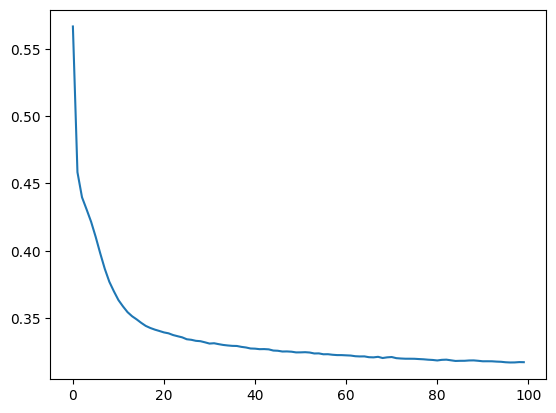

In [29]:
'''
yeh humara 1 se letak 100 epoch tak humara training error kaise reduced hua hai 
'''
plt.plot(history.history['loss'])

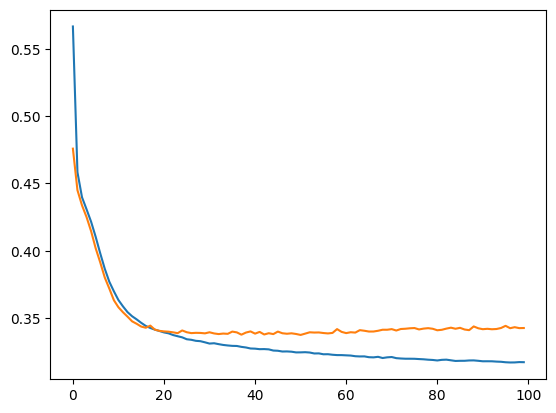

In [30]:
'''
isko aap directly compare kar sakte ho validation loss se 
'''
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

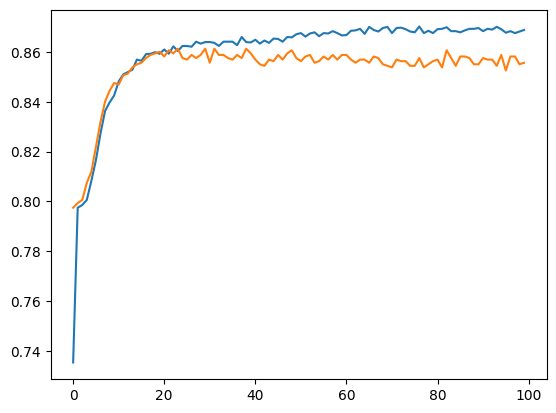

In [31]:
'''
isko aap directly compare kar sakte ho validation loss se 
'''
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])